In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets            #Has all source of complex datasets
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [40]:
np.random.seed(0)

In [41]:
n_pts = 500
X, y = datasets.make_circles(n_samples=n_pts, random_state = 123, noise=0.1, factor=0.2)
"""Points, Gets same random num each time, so we can reproduce the error every single time, 
Ensures that our data has some variance and we will make our NN more difficult to classify,

Relative size of smaller inner circle region to the larger outer circle 
factor = 1 is that both circle will be of same size
Diameter of inner circle is 20% larger than the outer circle """
print(X) 
print(y)

[[ 6.98553633e-01 -3.78289607e-01]
 [-2.48422424e-01  1.91071221e-01]
 [-1.78759035e-01  2.53697475e-01]
 [-7.30467124e-03 -2.59266690e-01]
 [-1.59844140e-01  2.66915921e-01]
 [-8.01071690e-01 -1.08656135e-01]
 [ 1.00816914e+00  2.07309295e-01]
 [ 4.39780516e-02 -2.80236072e-01]
 [-8.34853704e-02 -1.38114367e-01]
 [-9.88928208e-01 -9.26102014e-02]
 [ 8.83638650e-02  1.96647051e-01]
 [ 2.22010570e-01  5.62848283e-02]
 [ 7.74176833e-01  8.22258534e-01]
 [ 6.42098042e-02  1.77475658e-01]
 [ 3.29904597e-01 -6.76348560e-02]
 [ 9.37162087e-01  2.05987221e-01]
 [-2.00792169e-01  5.35547075e-02]
 [ 5.32997317e-02 -2.82138380e-01]
 [-9.93783900e-02 -3.28183801e-01]
 [ 1.02684872e+00 -2.66939738e-01]
 [-8.69193490e-01  6.85448273e-01]
 [-6.70339467e-03  2.44518907e-01]
 [ 2.31538284e-02 -8.12416827e-01]
 [ 1.03822075e-01  1.19298417e-01]
 [-9.57389366e-01 -3.49206448e-01]
 [-7.98982279e-02  2.30581375e-01]
 [ 1.31496662e-01  4.30585961e-02]
 [ 3.68169092e-02  9.51356467e-01]
 [ 6.71357733e-01 -8

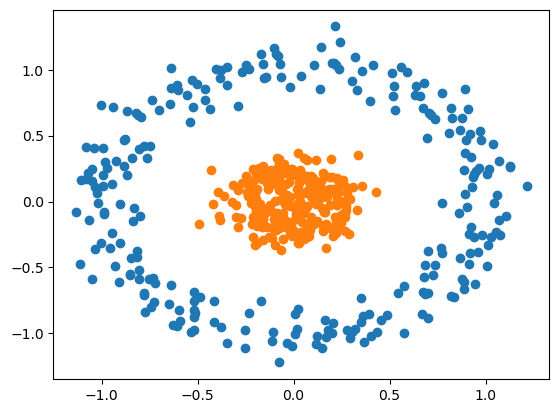

In [42]:
plt.scatter(X[y==0, 0], X[y==0, 1]) #Outer Region
plt.scatter(X[y==1, 0], X[y==1, 1]) #Inner Region

In [43]:
model = Sequential()
model.add(Dense(4, input_shape=(2,), activation='sigmoid'))
#Less nodes will cause inefficieny; More nodes Overfitting of data, No of nodes in i/p layer(x1,x2) 
model.add(Dense(1, activation='sigmoid'))
#No need of i/p layer as defined in previous line
model.compile(Adam(lr = 0.01), 'binary_crossentropy', metrics=['accuracy'])

In [44]:
h=model.fit(x=X, y=y, verbose=1, batch_size=20,epochs=100, shuffle='true')

Epoch 1/100
25/25 [==============================] - 0s 2ms/step - loss: 0.7289 - accuracy: 0.5000
Epoch 2/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6956 - accuracy: 0.6120
Epoch 3/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6948 - accuracy: 0.4980
Epoch 4/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6951 - accuracy: 0.3360
Epoch 5/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6938 - accuracy: 0.3980
Epoch 6/100
25/25 [==============================] - 0s 1ms/step - loss: 0.6953 - accuracy: 0.6080
Epoch 7/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6929 - accuracy: 0.5220
Epoch 8/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6945 - accuracy: 0.3740
Epoch 9/100
25/25 [==============================] - 0s 1ms/step - loss: 0.6930 - accuracy: 0.4880
Epoch 10/100
25/25 [==============================] - 0s 2ms/step - loss: 0.6928 - accuracy: 0.3300
Epoch 11/

Text(0.5, 1.0, 'accuracy')

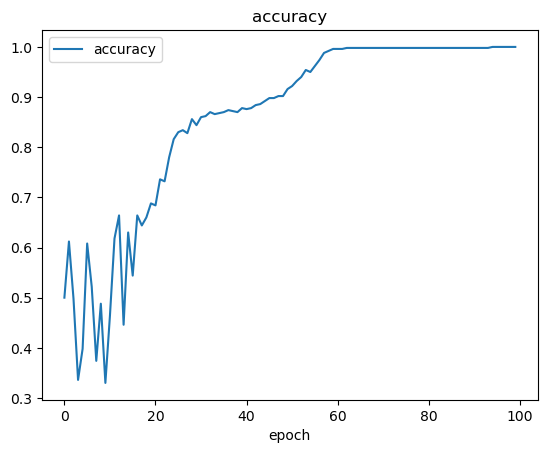

In [45]:
plt.plot(h.history['accuracy']) 
plt.xlabel('epoch')
plt.legend(['accuracy'])
plt.title('accuracy')

Text(0.5, 0, 'epoch')

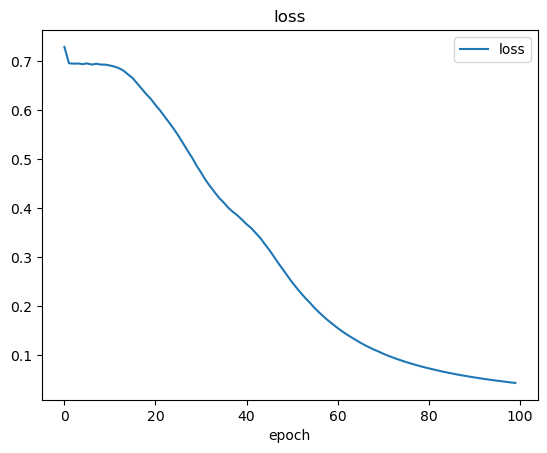

In [46]:
plt.plot(h.history['loss'])
plt.legend(['loss'])
plt.title('loss')
plt.xlabel('epoch')

In [47]:
def plot_decision_boundary(X, y, model):
    x_span = np.linspace(min(X[:,0]) - 0.25, max(X[:,0]) + 0.25)
    y_span = np.linspace(min(X[:,1]) - 0.25, max(X[:,1]) + 0.25)
    xx, yy = np.meshgrid(x_span, y_span)
    grid = np.c_[xx.ravel(), yy.ravel()]
    pred_func = model.predict(grid)
    z = pred_func.reshape(xx.shape)
    plt.contourf(xx, yy, z)                 #Contour zones represents the distinct threshold of prob

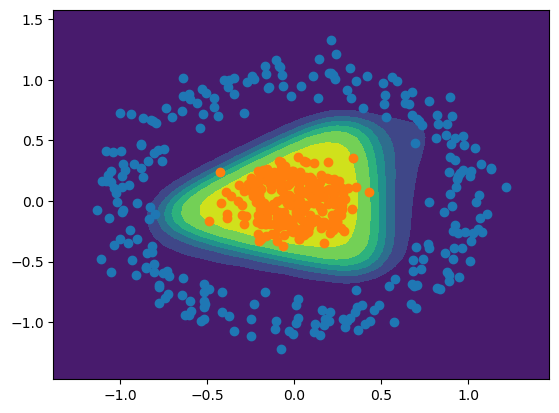

In [48]:
plot_decision_boundary(X, y, model)
plt.scatter(X[y==0, 0], X[y==0, 1])
plt.scatter(X[y==1, 0], X[y==1, 1])

Prediction is:  [[0.05702767]]


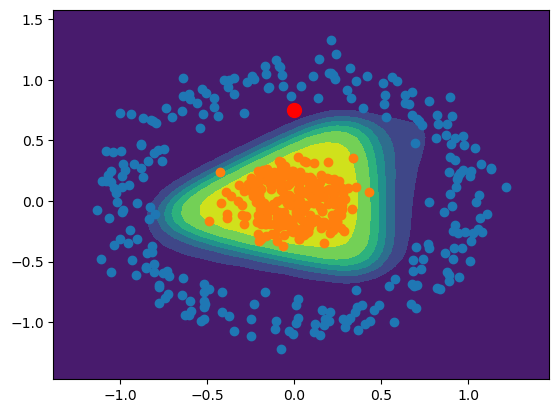

In [49]:
plot_decision_boundary(X, y, model)
plt.scatter(X[y==0, 0], X[y==0, 1])
plt.scatter(X[y==1, 0], X[y==1, 1])
 
x = 0
y = 0.75
 
point = np.array([[x, y]])
predict = model.predict(point)
plt.plot([x], [y], marker='o', markersize=10, color="red")
print("Prediction is: ", predict)